# Vortex Induced Vibrations


In [82]:
import numpy as np
import matplotlib.pyplot as plt


L = 160
rho_w = 1027
rho_c = 7880
D = np.sqrt(4*575/(rho_c*np.pi))
T = 3500
b = 10
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
omega_n = (np.pi / L) * np.sqrt(T / m_eff)
zeta = b / (2 * omega_n * m_eff)

epsilon = 0.3
A_coupling = 12.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0


In [83]:
def rhs(t, x, U):

    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    # Lift 
    Lift = 0.5 * rho_w * U**2 * D * L * q

    # Structural 
    y_ddot = (-2*zeta*omega_n*y_dot - omega_n**2*y + Lift/m_eff)

    # Wake 
    q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [84]:
def rk4(f, t, x, dt, U):

    k1 = f(t, x, U)
    k2 = f(t + dt/2, x + dt/2 * k1, U)
    k3 = f(t + dt/2, x + dt/2 * k2, U)
    k4 = f(t + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [85]:
def comp_x(dt, t_end, U):
    time = np.arange(0, t_end, dt)
    x = np.array([0.01, 0.0, 0.0, 0.0])
    solution = np.zeros((len(time), 4))

    for i, t in enumerate(time):
        solution[i] = x
        x = rk4(rhs, t, x, dt, U)

    return time, solution

In [86]:
def compute_amplitude(dt, t_end, U):

    time, solution = comp_x(dt , t_end, U)

    y = solution[:,2]

    # Remove transient (last 30%)
    cutoff = int(0.7 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

Amplitude for U=0.40 m/s: 150.42 mm
Amplitude for U=0.55 m/s: 1268.76 mm
Amplitude for U=0.70 m/s: 7728513.07 mm


C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar multiply
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar power
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\3322621912.py:8: RuntimeWarning: invalid value encountered in add
  return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


Amplitude for U=0.85 m/s: nan mm
Amplitude for U=1.00 m/s: nan mm
Simulation completed in 4.76 seconds.


<Figure size 1200x800 with 0 Axes>

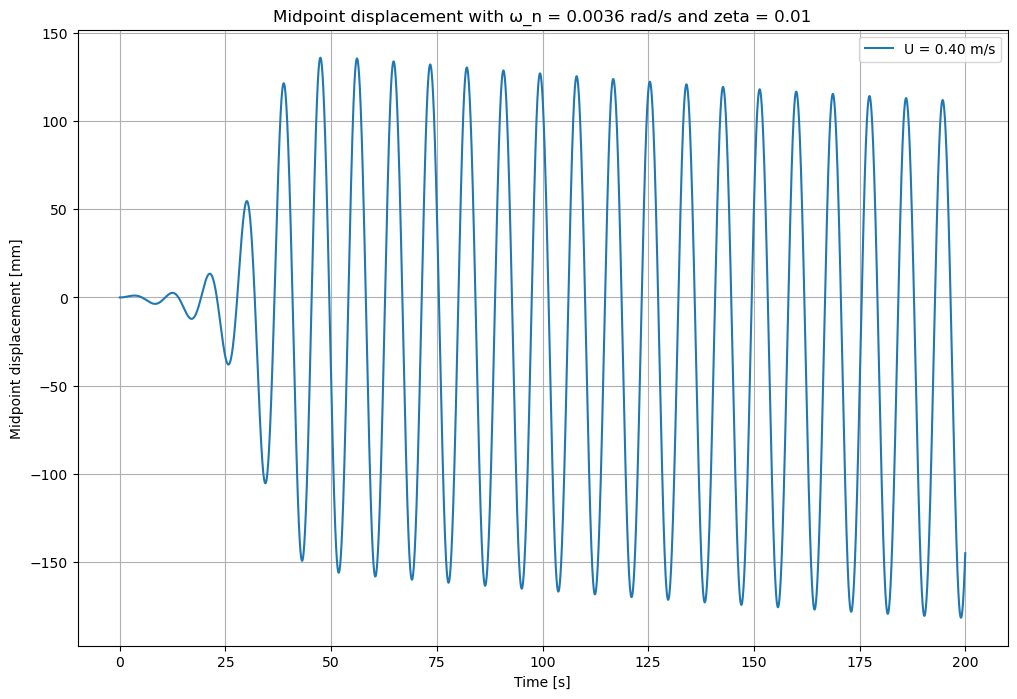

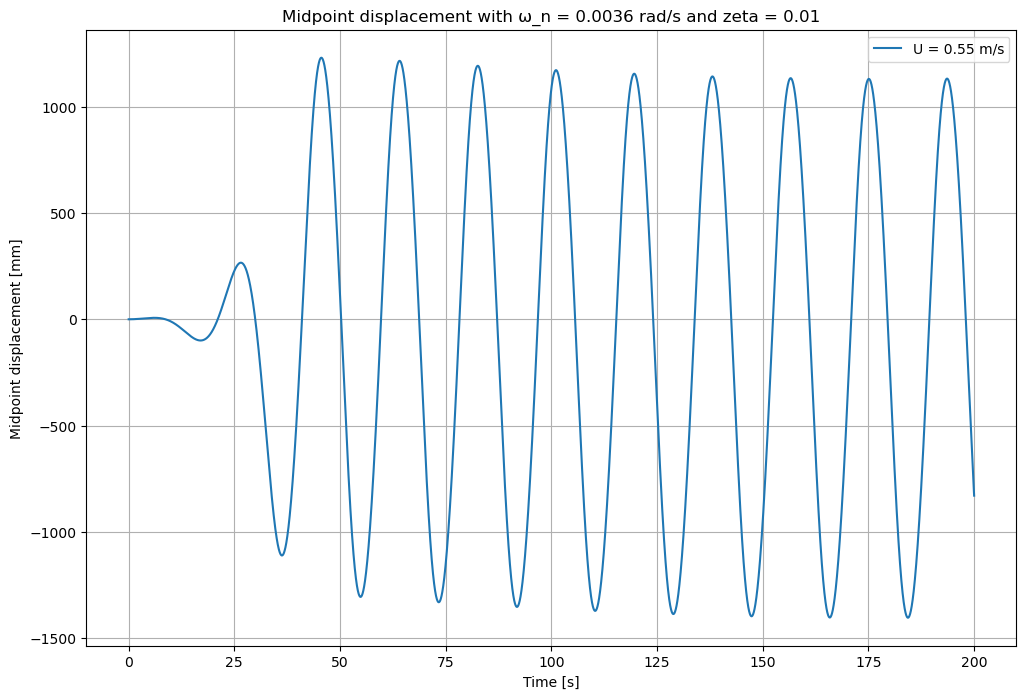

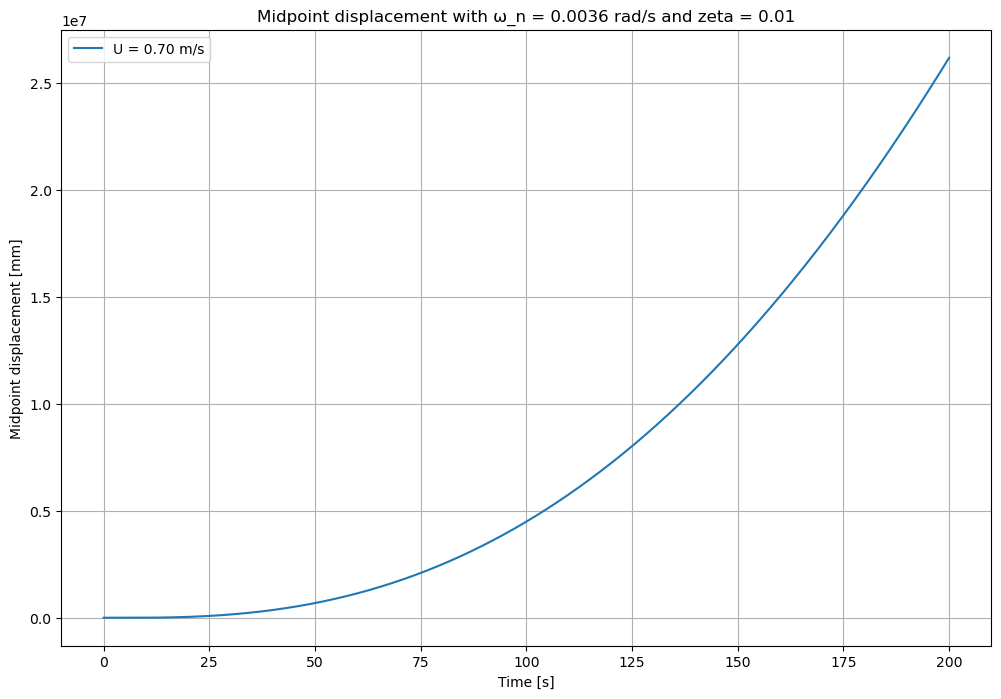

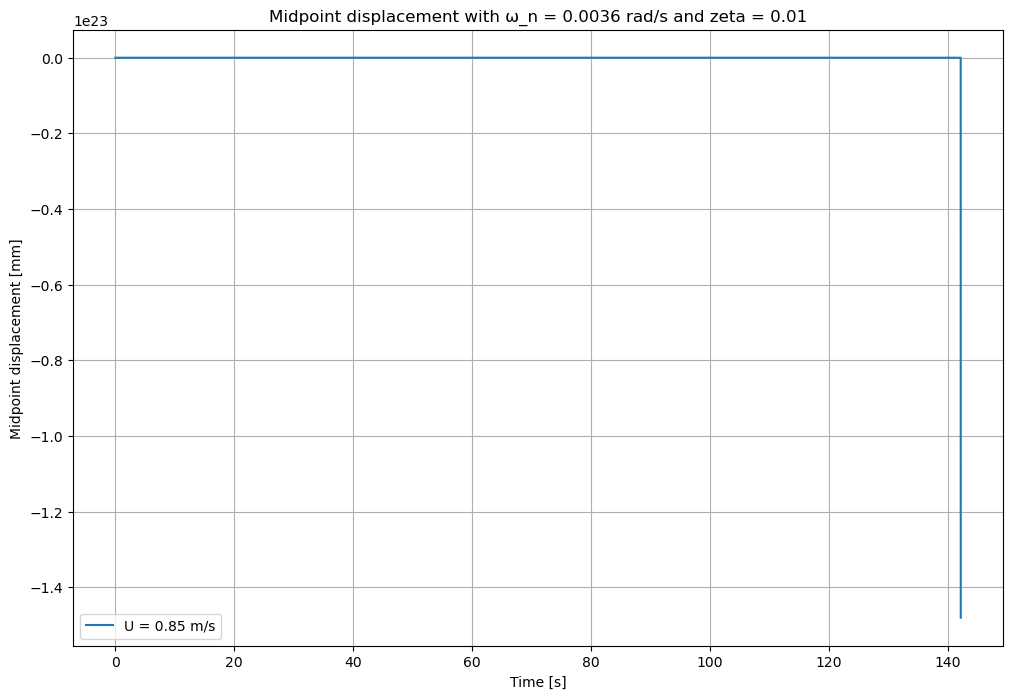

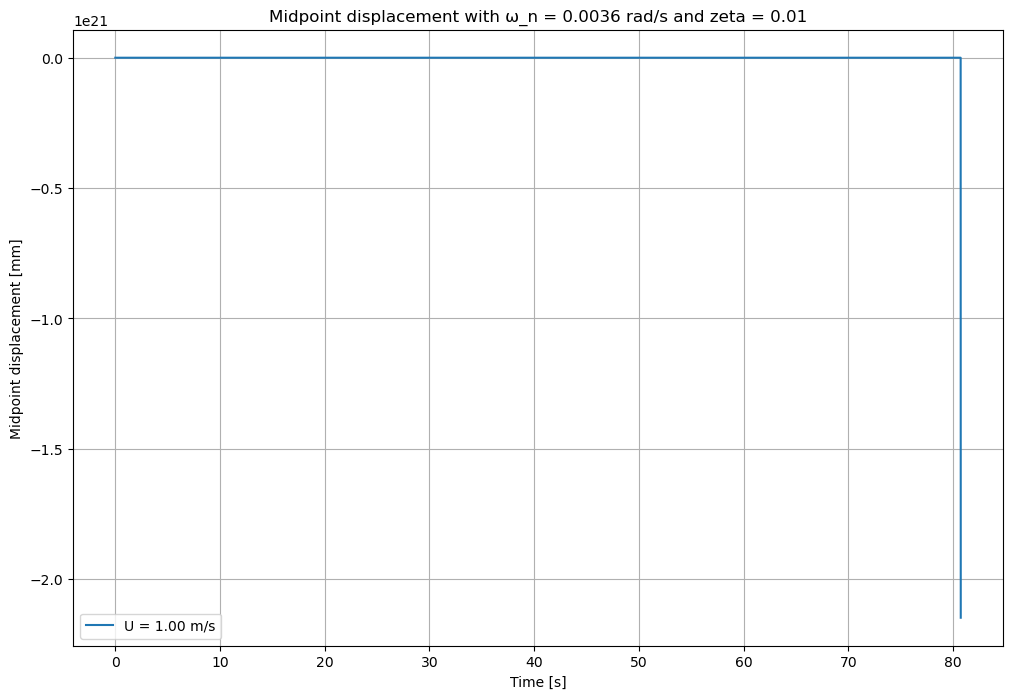

In [87]:
U_range = np.linspace(0.4, 1, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.figure(figsize=(12,8))
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    plt.xlabel("Time [s]")
    plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
    plt.ylabel("Midpoint displacement [mm]")
    plt.legend()
    plt.grid()

    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(dt, t_end, U)*1000:.2f} mm")

end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")


Solving for U = 0.400
Solving for U = 0.550
Solving for U = 0.700
Solving for U = 0.850


C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar multiply
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar power
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\3322621912.py:8: RuntimeWarning: invalid value encountered in add
  return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


Solving for U = 1.000


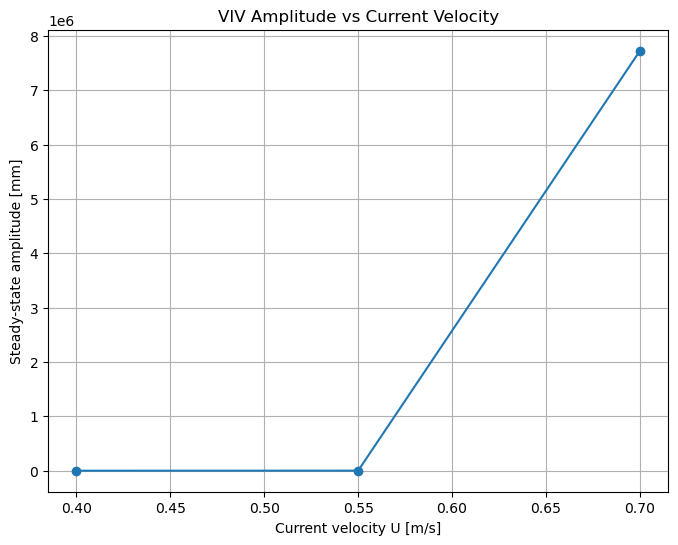

In [88]:
U_values = np.linspace(0.4, 1.0, 5)
amplitudes = []

for U in U_values:
    print(f"Solving for U = {U:.3f}")
    amp = compute_amplitude(dt , t_end, U)
    amplitudes.append(amp)

plt.figure(figsize=(8,6))
plt.plot(U_values, 1000 * np.array(amplitudes), marker='o')
plt.xlabel("Current velocity U [m/s]")
plt.ylabel("Steady-state amplitude [mm]")
plt.title("VIV Amplitude vs Current Velocity")
plt.grid(True)


Amplitude for U=0.40 m/s: 150.42 mm
Amplitude for U=0.55 m/s: 1268.76 mm
Amplitude for U=0.70 m/s: 7728513.07 mm


C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar multiply
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: overflow encountered in scalar power
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\1140559922.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)
C:\Users\lucwi\AppData\Local\Temp\ipykernel_28072\3322621912.py:8: RuntimeWarning: invalid value encountered in add
  return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


Amplitude for U=0.85 m/s: nan mm
Amplitude for U=1.00 m/s: nan mm
Simulation completed in 5.78 seconds.


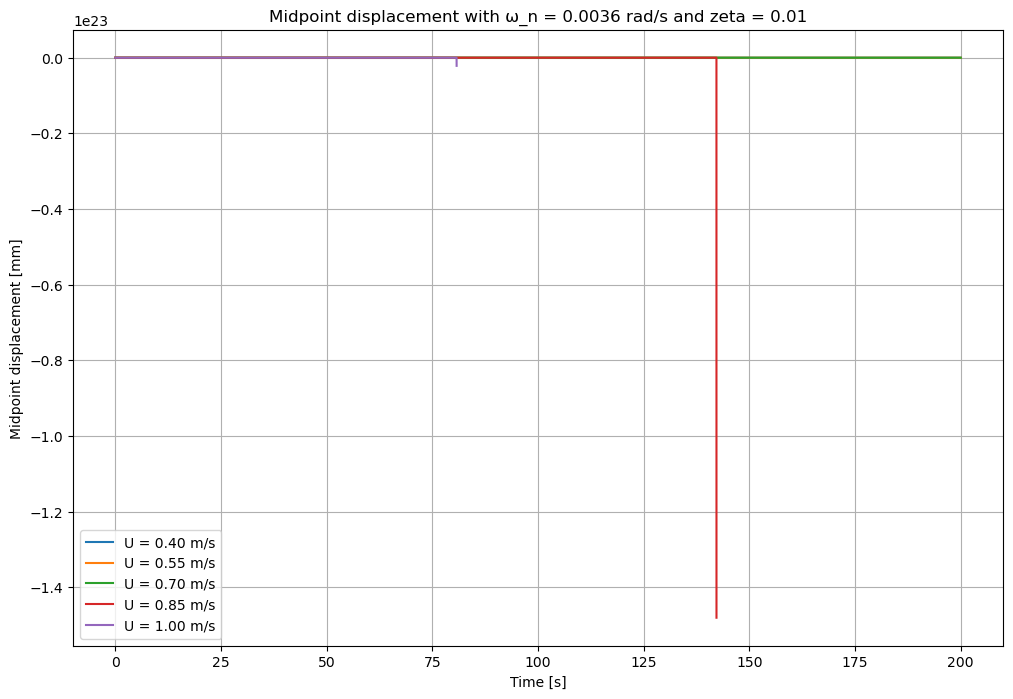

In [89]:
U_range = np.linspace(0.4, 1.0, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(dt, t_end, U)*1000:.2f} mm")

plt.xlabel("Time [s]")
plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
plt.ylabel("Midpoint displacement [mm]")
plt.legend()
plt.grid()


end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")

# Dimensionless


In [91]:
L = 160.0
D = np.sqrt(4*575/(rho_c*np.pi))
rho_w = 1027
rho_c = 7880
T = 3500
b = 10
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
m_star = rho_c * A_cross 
m_a_star = rho_w * A_cross 
m_eff_star = m_star + m_a_star
m_dubble_star = m / m_a
omega_n1 = (np.pi / L)  * np.sqrt(T / m_eff_star)
print(f"Natural frequency (rad/s): {omega_n1:.4f}")

zeta = b / (2 * omega_n1 * m_eff_star)
f_n1 = omega_n1 / (2 *np.pi)
print(f"Natural frequency (Hz): {f_n1:.4f}")


epsilon = 0.3
A_coupling = 16.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0

print(m_dubble_star)



Natural frequency (rad/s): 0.0456
Natural frequency (Hz): 0.0073
7.672833495618306


In [92]:
print(D)

0.30480765721399466


# Make variables dimensionless

In [93]:
def rhs(tau, x, U):
    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    omega_s = 2 * np.pi * St * U / D
    Omega_n = omega_n1 / omega_s

    hydro = (rho_w * D**2) / (m_eff_star * 8 * np.pi**2 * St**2)
    nonlinear_term = (-2 * np.pi * St * y_dot * Cx0_hat + ((Cy1_hat /q1_hat) * q))

    F = hydro * nonlinear_term * np.sqrt(1 + 4 * np.pi**2 * St**2 * y_dot**2)

    y_ddot = -2 * zeta * Omega_n * y_dot - Omega_n**2 * y + F
    q_ddot = -epsilon * (q**2 - 1) * q_dot - q + A_coupling * y_ddot

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [94]:
def rk4(f, tau, x, dt, U):

    k1 = f(tau, x, U)
    k2 = f(tau + dt/2, x + dt/2 * k1, U)
    k3 = f(tau + dt/2, x + dt/2 * k2, U)
    k4 = f(tau + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [95]:
def comp_x(U, x0):
    dtau = 0.005
    tau_end = 200
    tau = np.arange(0, tau_end, dtau)

    x = np.array(x0, dtype=float)
    solution = np.zeros((len(tau), 4))

    for i, tau_i in enumerate(tau):
        solution[i] = x
        x = rk4(rhs, tau_i, x, dtau, U)

    return tau, solution

In [96]:
def compute_amplitude(U):

    tau, solution = comp_x(U)
    y = solution[:,2]
    cutoff = int(0.9 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

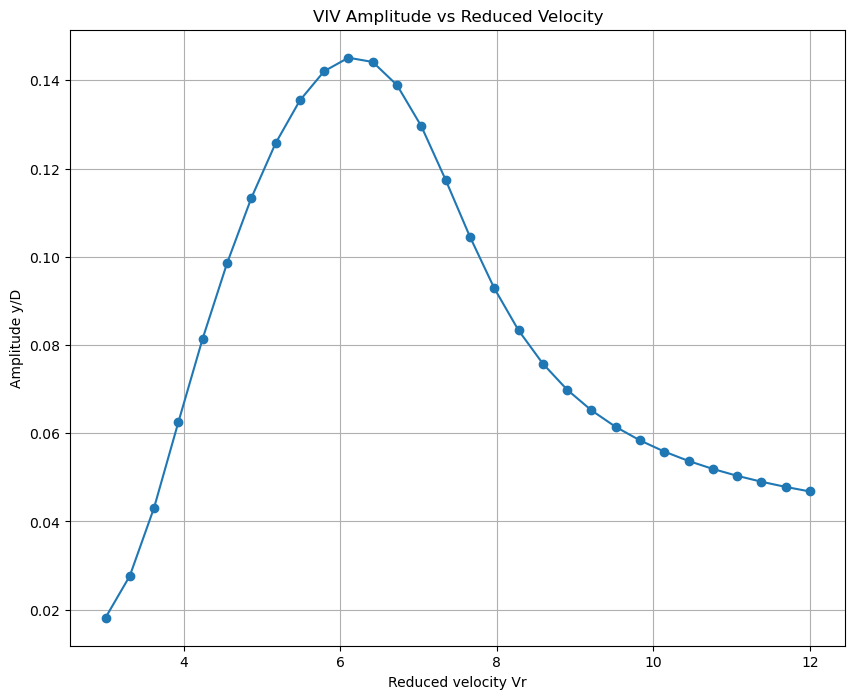

In [97]:
V_r = np.linspace(3, 12, 30)
U_values = V_r * D * f_n1

amplitudes = []
x0 = np.array([0.01, 0.0, 0.0, 0.0])   # start once

for U in U_values:
    tau, solution = comp_x(U, x0)

    y = solution[:, 2]
    cutoff = int(0.85 * len(y))
    y_steady = y[cutoff:]
    amp = 0.5 * (np.max(y_steady) - np.min(y_steady))
    amplitudes.append(amp)

plt.figure(figsize=(10,8))
plt.plot(V_r, amplitudes, marker='o')
plt.xlabel("Reduced velocity Vr")
plt.ylabel("Amplitude y/D")
plt.title("VIV Amplitude vs Reduced Velocity")
plt.grid()



In [98]:
print(U_values)


[0.00663124 0.00731723 0.00800322 0.00868921 0.0093752  0.01006119
 0.01074718 0.01143317 0.01211916 0.01280515 0.01349114 0.01417713
 0.01486312 0.01554911 0.0162351  0.01692109 0.01760708 0.01829307
 0.01897906 0.01966505 0.02035104 0.02103703 0.02172302 0.02240901
 0.023095   0.02378099 0.02446698 0.02515297 0.02583896 0.02652495]


In [99]:
for U_i in U_values:

    if U_i > 0.05:
        tau, solution = comp_x(U_i, x0)

        y = solution[:,2]

        plt.figure(figsize=(8,5))
        plt.plot(tau, y)
        plt.xlabel("Dimensionless time τ")
        plt.ylabel("Displacement y/D")
        plt.title(f"Cylinder displacement for U = {U_i:.3f} m/s")
        plt.grid(True)
        plt.show()

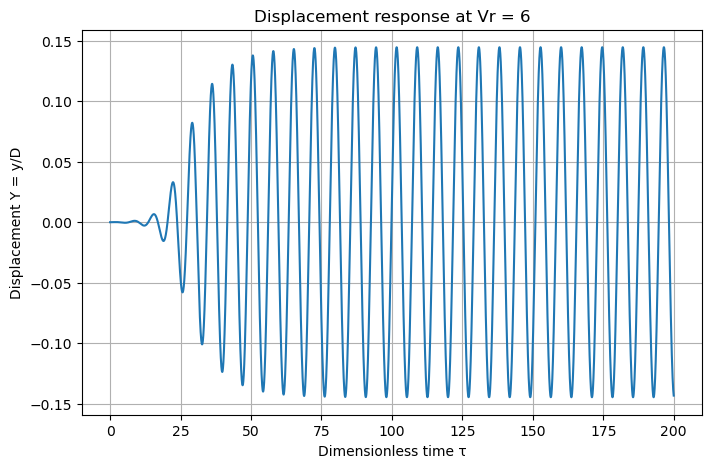

In [100]:
Vr_lockin = 6
U_lockin = Vr_lockin * f_n1 * D
tau, solution = comp_x(U_lockin, x0)

Y = solution[:,2]

plt.figure(figsize=(8,5))
plt.plot(tau, Y)
plt.xlabel("Dimensionless time τ")
plt.ylabel("Displacement Y = y/D")
plt.title(f"Displacement response at Vr = {Vr_lockin}")
plt.grid(True)
plt.show()


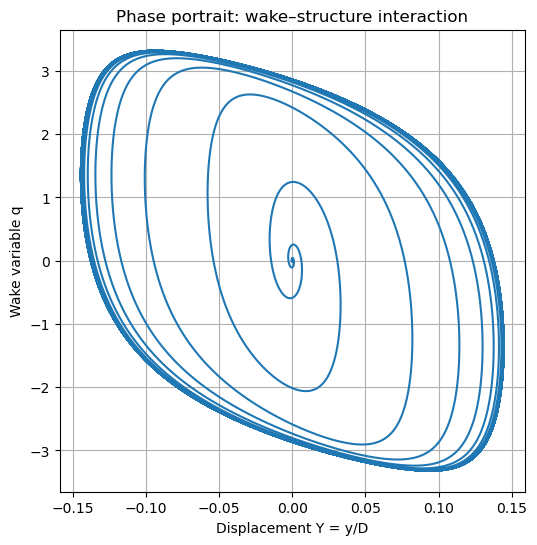

In [101]:
q = solution[:,0]
Y = solution[:,2]

plt.figure(figsize=(6,6))
plt.plot(Y, q)
plt.xlabel("Displacement Y = y/D")
plt.ylabel("Wake variable q")
plt.title("Phase portrait: wake–structure interaction")
plt.grid(True)
plt.show()